# Home Credit Default Risk
 https://www.kaggle.com/datasets/megancrenshaw/home-credit-default-risk

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Carga de datos
Se parte de `eight_columns.csv`, que contiene las variables seleccionadas para el taller. Como ese fichero no incluye el identificador de cliente, se recupera `SK_ID_CURR` desde `application_train.csv` y se usa como indice para mantener trazabilidad por cliente.

In [2]:
df = pd.read_csv('eight_columns.csv')

client_ids = pd.read_csv('application_train.csv', usecols=['SK_ID_CURR'])
assert len(client_ids) == len(df), 'SK_ID_CURR no esta alineado con eight_columns.csv'

df.index = client_ids['SK_ID_CURR']
df.index.name = 'SK_ID_CURR'

In [3]:
df.shape

(307511, 9)

## EDA 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307511 entries, 100002 to 456255
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   TARGET            307511 non-null  int64  
 1   CODE_GENDER       307511 non-null  object 
 2   AMT_INCOME_TOTAL  307511 non-null  float64
 3   AMT_CREDIT        307511 non-null  float64
 4   AMT_ANNUITY       307499 non-null  float64
 5   DAYS_BIRTH        307511 non-null  int64  
 6   EXT_SOURCE_1      134133 non-null  float64
 7   EXT_SOURCE_2      306851 non-null  float64
 8   EXT_SOURCE_3      246546 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 23.5+ MB


In [5]:
df.describe()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,307511.000000,3.075110e+05,3.075110e+05,307499.000000,307511.000000,134133.000000,3.068510e+05,246546.000000
mean,0.080729,1.687979e+05,5.990260e+05,27108.573909,-16036.995067,0.502130,5.143927e-01,0.510853
std,0.272419,2.371231e+05,4.024908e+05,14493.737315,4363.988632,0.211062,1.910602e-01,0.194844
min,0.000000,2.565000e+04,4.500000e+04,1615.500000,-25229.000000,0.014568,8.173617e-08,0.000527
25%,0.000000,1.125000e+05,2.700000e+05,16524.000000,-19682.000000,0.334007,3.924574e-01,0.370650
50%,0.000000,1.471500e+05,5.135310e+05,24903.000000,-15750.000000,0.505998,5.659614e-01,0.535276
75%,0.000000,2.025000e+05,8.086500e+05,34596.000000,-12413.000000,0.675053,6.636171e-01,0.669057
max,1.000000,1.170000e+08,4.050000e+06,258025.500000,-7489.000000,0.962693,8.549997e-01,0.896010


In [6]:
df['DAYS_BIRTH'] = abs(df['DAYS_BIRTH']) / 365

### Missing values
Primero se mide el volumen de nulos. Para `EXT_SOURCE_1`, `EXT_SOURCE_2` y `EXT_SOURCE_3` se guarda un flag binario de incertidumbre antes de imputar, de forma que el modelo pueda distinguir un valor observado de un valor rellenado.

In [7]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * mis_val / len(df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table = mis_val_table.rename(
        columns={0: 'Missing Values', 1: '% of Total Values'}
    )

    mis_val_table = (
        mis_val_table[mis_val_table.iloc[:, 1] != 0]
        .sort_values('% of Total Values', ascending=False)
        .round(1)
    )

    print(
        'Your selected dataframe has ' + str(df.shape[1]) + ' columns.\n'
        'There are ' + str(mis_val_table.shape[0]) + ' columns that have missing values.'
    )

    return mis_val_table

In [8]:
missing_values = missing_values_table(df)
missing_values.head(20)

Your selected dataframe has 9 columns.
There are 4 columns that have missing values.


,Missing Values,% of Total Values
EXT_SOURCE_1,173378,56.4
EXT_SOURCE_3,60965,19.8
EXT_SOURCE_2,660,0.2
AMT_ANNUITY,12,0.0


In [9]:
ext_source_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
flag_cols = [f'{col}_MISSING' for col in ext_source_cols]

# Flags binarios: 1 si el EXT_SOURCE venia vacio originalmente, 0 si estaba observado.
flags_missing = df[ext_source_cols].isna().astype(int)
flags_missing.columns = flag_cols
flags_missing.index.name = 'SK_ID_CURR'

flags_missing.to_csv('ext_source_missing_flags.csv')
flags_missing.head()

,EXT_SOURCE_1_MISSING,EXT_SOURCE_2_MISSING,EXT_SOURCE_3_MISSING
SK_ID_CURR,,,
100002,0,0,0
100003,0,0,1
100004,1,0,0
100006,1,0,1
100007,1,0,1


### Desbalanceo de clases

- Hay menos hombres que mujeres.
- En esta muestra, los hombres tienen mayor proporcion de `TARGET = 1`.
- Los valores `XNA` de genero se imputan como hombre por su impacto minimo.
- El `TARGET` esta desbalanceado: aproximadamente 90% clase 0 y 10% clase 1.

<Axes: xlabel='TARGET'>

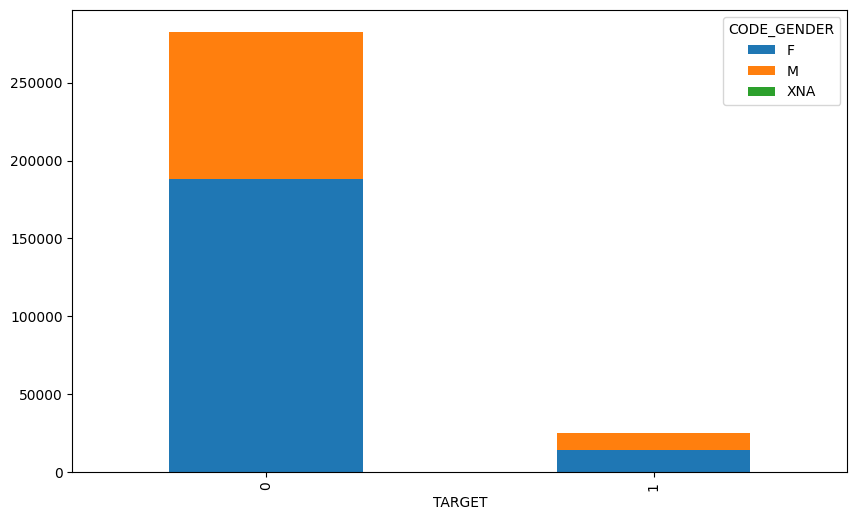

In [10]:
# Comprobar el desbalanceo entre TARGET y genero.
df.groupby(['TARGET', 'CODE_GENDER']).size().unstack().plot(
    kind='bar', stacked=True, figsize=(10, 6)
)

### Variable categorica sensible
`CODE_GENDER` es la variable sensible. Se codifica como 0 para hombre y 1 para mujer; los valores no informados (`XNA`) se asignan a 0 por su frecuencia residual.

In [11]:
df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1}).fillna(0).astype(int)

### Correlation Matrix

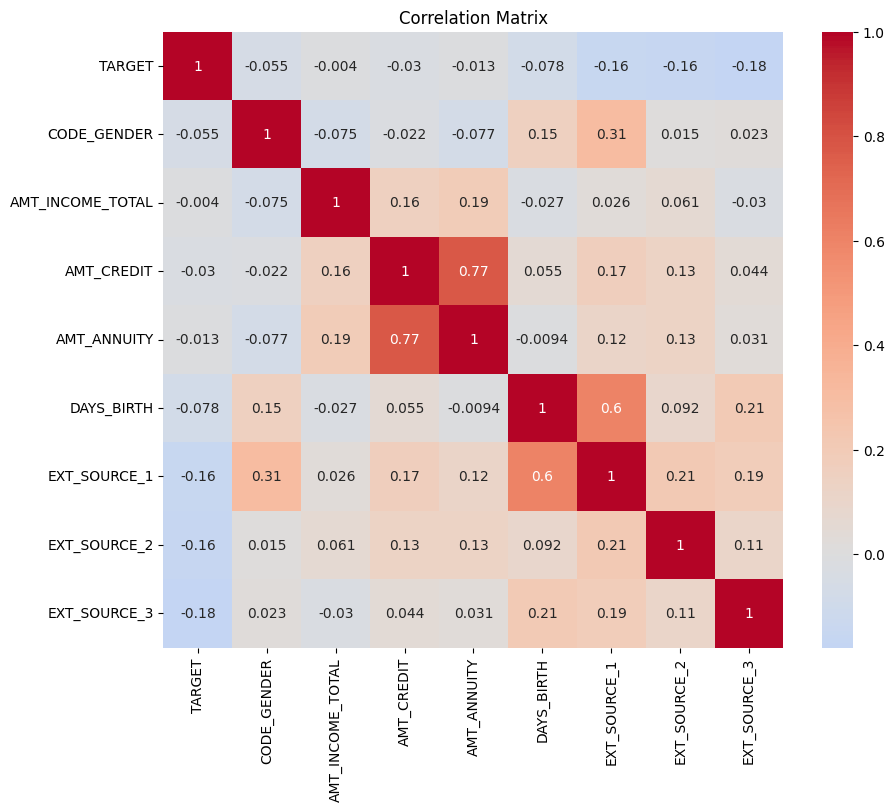

In [12]:
# matriz de correlaciones entre todas las variables

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

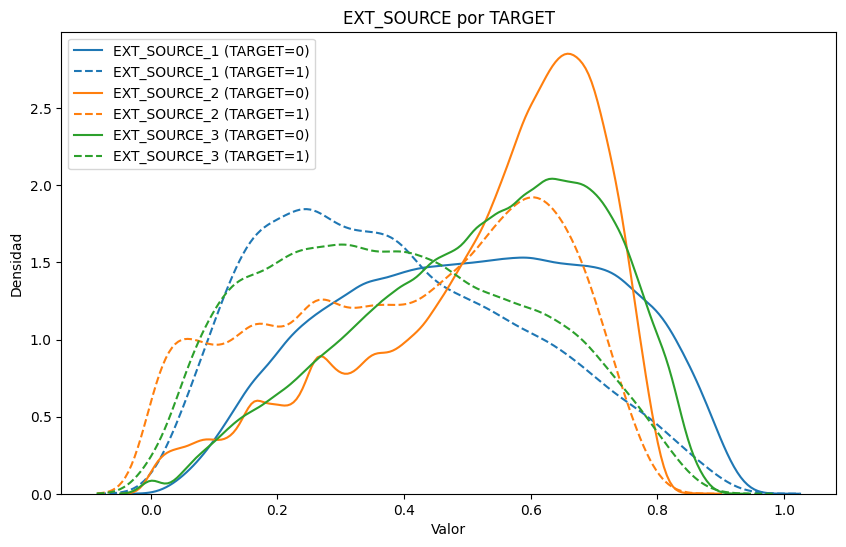

In [13]:
plt.figure(figsize=(10,6))

variables = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
colores = ['tab:blue', 'tab:orange', 'tab:green']

for var, color in zip(variables, colores):

    sns.kdeplot(
        data=df[df['TARGET']==0],
        x=var,
        color=color,
        linestyle='-',
        label=f'{var} (TARGET=0)'
    )

    sns.kdeplot(
        data=df[df['TARGET']==1],
        x=var,
        color=color,
        linestyle='--',
        label=f'{var} (TARGET=1)'
    )

plt.title('EXT_SOURCE por TARGET')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend()
plt.show()

## Ratio de endeudamiento
Se crea una variable derivada sencilla: credito solicitado dividido entre ingresos totales.

In [14]:
df['RATIO_ENDEUDAMIENTO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df[['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'RATIO_ENDEUDAMIENTO']].head()

,AMT_CREDIT,AMT_INCOME_TOTAL,RATIO_ENDEUDAMIENTO
SK_ID_CURR,,,
100002,406597.5,202500.0,2.007889
100003,1293502.5,270000.0,4.790750
100004,135000.0,67500.0,2.000000
100006,312682.5,135000.0,2.316167
100007,513000.0,121500.0,4.222222


¿Relación entre el ratio de endeudamiento y el la edad?

/tmp/ipykernel_1610/4038338465.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 6000), random_state=42))


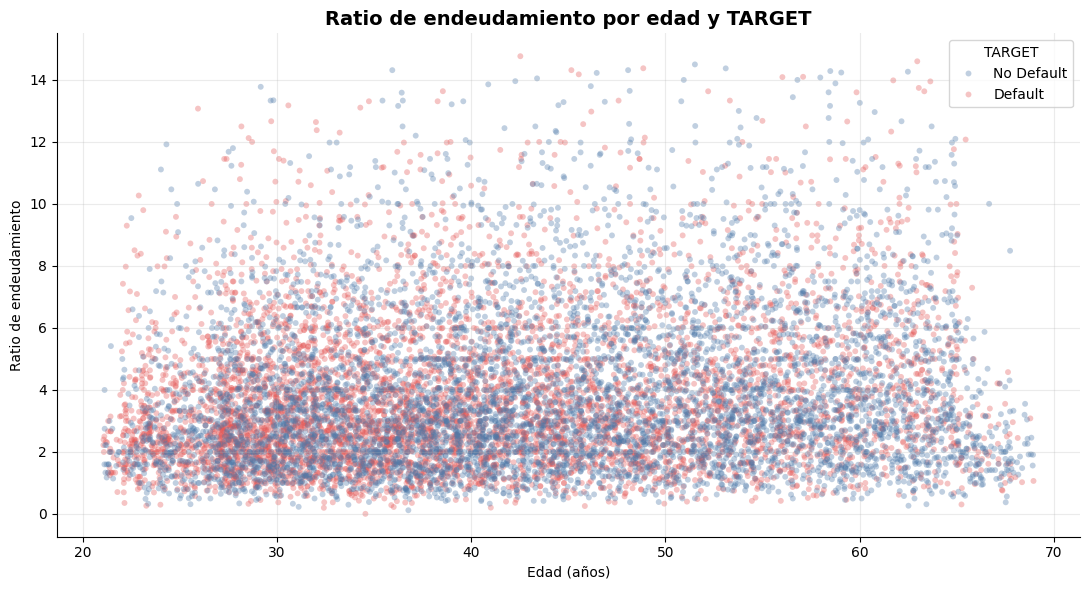

In [15]:
# Scatterplot entre RATIO_ENDEUDAMIENTO y DAYS_BIRTH, coloreado por TARGET
plot_df = df[['DAYS_BIRTH', 'RATIO_ENDEUDAMIENTO', 'TARGET']].dropna().copy()
plot_df['TARGET_LABEL'] = plot_df['TARGET'].map({0: 'No Default', 1: 'Default'})

# Recorte visual para que los outliers no aplasten la nube principal de puntos
limite_y = plot_df['RATIO_ENDEUDAMIENTO'].quantile(0.995)
plot_df = plot_df[plot_df['RATIO_ENDEUDAMIENTO'].between(0, limite_y)]

# Muestra estratificada: mejora la legibilidad y conserva ambas clases
plot_sample = (
    plot_df
    .groupby('TARGET_LABEL', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 6000), random_state=42))
)

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=plot_sample,
    x='DAYS_BIRTH',
    y='RATIO_ENDEUDAMIENTO',
    hue='TARGET_LABEL',
    hue_order=['No Default', 'Default'],
    palette={'No Default': '#4C78A8', 'Default': '#E45756'},
    alpha=0.35,
    s=18,
    linewidth=0,
)

plt.title('Ratio de endeudamiento por edad y TARGET', fontsize=14, weight='bold')
plt.xlabel('Edad (años)')
plt.ylabel('Ratio de endeudamiento')
plt.grid(True, alpha=0.25)
plt.legend(title='TARGET', frameon=True)
sns.despine()
plt.tight_layout()



In [16]:
import keras
import tensorflow as tf
print(f'Keras version: {keras.__version__}')
print(f'TensorFlow version: {tf.__version__}')


2026-06-23 18:16:38.179024: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-23 18:16:38.481194: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-23 18:16:39.753924: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Keras version: 2.13.1
TensorFlow version: 2.13.0
